##Modelo de predicción de abandono de carrito

Entrena y evalúa un modelo de clasificación binaria sobre `session_features`
(una fila por sesión con carrito). La etiqueta es `label_abandonment`:

- `1` = la sesión abandonó el carrito (sin compra)
- `0` = la sesión terminó en compra


In [0]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd

## 1. Cargar datos y ver el balance de clases

In [0]:
# dataset ya listo para ml (una fila por sesion con carrito)
df = spark.read.table("ecommerce_history.events_history.session_features")
print("filas:", df.count())
display(df.limit(5))

filas: 983986


session_id,user_id,session_start,cohort_month,label_abandonment,duration_seconds,event_count,view_count,cart_count,remove_count,distinct_products,distinct_categories,distinct_brands,avg_event_price,max_event_price,cart_value_events,start_hour,is_weekend,first_category,first_price_range
0a56ae8eda1d12552d9f9d6b2158bfef7d509353d55a3fe5bc626595f6382490,380782835,2019-12-21T11:18:48.000Z,2019-12,1,1977,43,3,22,18,25,4,6,9.585581,19.05,229.9,11,1,unknown,01_bajo_<10
a109f834484a47af438cd171afdec7a61c878b7aa7f99ecae876824bd99c5a4d,583075596,2019-12-06T20:05:47.000Z,2019-12,1,2124,15,12,1,2,10,6,5,9.798667,16.19,16.19,20,0,unknown,02_medio_10_49.99
c8ef60e07e316c9b3cc7af5bdb3b7751664a7af1e0d6ccee6957bb8da0a47455,608915051,2020-02-01T11:29:24.000Z,2020-02,1,0,1,0,1,0,1,1,1,8.57,8.57,8.57,11,1,unknown,01_bajo_<10
60ded1476cc07695973e1e1b3e0e602624607dcfb5810a5ab9601551fd6b2752,564039071,2019-10-29T07:50:01.000Z,2019-10,1,330,9,8,1,0,6,2,2,16.872222,21.59,17.94,7,0,unknown,02_medio_10_49.99
bd2eb21bb893684581e27fdfda9df5ea680b8ae9afb5e792465a1d7a774cae83,557591661,2019-10-17T12:18:41.000Z,2019-10,1,1638,15,5,6,4,10,5,4,4.342667,5.56,24.34,12,0,unknown,01_bajo_<10


In [0]:
# balance de clases: 1 = abandono, 0 = compra
df.groupBy("label_abandonment").count().show()

+-----------------+------+
|label_abandonment| count|
+-----------------+------+
|                1|857729|
|                0|126257|
+-----------------+------+



## 2. Selección de features y control de fuga de información

**Importante:** se excluye `event_count` a propósito.

`event_count = view_count + cart_count + remove_count + purchase_count`.
Como `purchase_count` no es feature, si dejara `event_count` el modelo podría
calcular `purchase_count = event_count - view - cart - remove` y con eso deducir
la etiqueta directamente (abandono = sin compra). El resultado serían métricas
casi perfectas pero inválidas. Por eso `event_count` queda fuera.

También se deja `cohort_month` fuera de las features (no generaliza a meses
futuros; solo sirve para un split temporal opcional).

In [0]:
label_col = "label_abandonment"

num_cols = [
    "duration_seconds", "view_count", "cart_count", "remove_count",
    "distinct_products", "distinct_categories", "distinct_brands",
    "avg_event_price", "max_event_price", "cart_value_events",
    "start_hour", "is_weekend",
]
cat_cols = ["first_category", "first_price_range"]

# defensivo: sin nulos en numericas
df = df.na.fill(0, subset=num_cols)

## 3. Peso por clase (desbalance)

El abandono suele ser la clase mayoritaria. Se agrega un peso inverso a la
frecuencia para que el modelo no ignore la clase minoritaria.

In [0]:
n = df.count()
n_pos = df.filter(F.col(label_col) == 1).count()
n_neg = n - n_pos
w_pos = n / (2.0 * n_pos)
w_neg = n / (2.0 * n_neg)
df = df.withColumn(
    "weight",
    F.when(F.col(label_col) == 1, F.lit(w_pos)).otherwise(F.lit(w_neg)),
)
print(f"positivos={n_pos} negativos={n_neg} w_pos={w_pos:.3f} w_neg={w_neg:.3f}")

positivos=857729 negativos=126257 w_pos=0.574 w_neg=3.897


## 4. Split train / test

In [0]:
# split aleatorio 80/20 (con este volumen la proporcion de clases se conserva bien)
train, test = df.randomSplit([0.8, 0.2], seed=42)
train, test = df.randomSplit([0.8, 0.2], seed=42)
print("train:", train.count(), "test:", test.count())

train: 787341 test: 196645


## 5. Pipeline de features

Indexado + one-hot para las categóricas y ensamblado de todo a un solo vector.

In [0]:
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe") for c in cat_cols]
assembler = VectorAssembler(
    inputCols=num_cols + [c + "_ohe" for c in cat_cols],
    outputCol="features",
    handleInvalid="keep",
)
prep = indexers + encoders + [assembler]

## 6. Entrenamiento

Dos modelos: una regresión logística como baseline interpretable y un random
forest como modelo principal, además da la importancia de variables

In [0]:
lr = LogisticRegression(featuresCol="features", labelCol=label_col,
                        weightCol="weight", maxIter=50)
rf = RandomForestClassifier(featuresCol="features", labelCol=label_col,
                            weightCol="weight", numTrees=100, maxDepth=8, seed=42)

lr_model = Pipeline(stages=prep + [lr]).fit(train)
rf_model = Pipeline(stages=prep + [rf]).fit(train)

## 7. Evaluación

Con clases desbalanceadas la exactitud engaña, así que se reportan AUC-ROC,
AUC-PR y precisión/recall/F1 de la clase positiva (abandono).

In [0]:
def evaluar(modelo, test, nombre, label_col="label_abandonment"):
    pred = modelo.transform(test)
    auc_roc = BinaryClassificationEvaluator(labelCol=label_col, metricName="areaUnderROC").evaluate(pred)
    auc_pr = BinaryClassificationEvaluator(labelCol=label_col, metricName="areaUnderPR").evaluate(pred)
    # metricas de la clase positiva (abandono = 1)
    tp = pred.filter((F.col(label_col) == 1) & (F.col("prediction") == 1)).count()
    fp = pred.filter((F.col(label_col) == 0) & (F.col("prediction") == 1)).count()
    fn = pred.filter((F.col(label_col) == 1) & (F.col("prediction") == 0)).count()
    tn = pred.filter((F.col(label_col) == 0) & (F.col("prediction") == 0)).count()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    acc = (tp + tn) / (tp + fp + fn + tn)
    print(f"[{nombre}] auc_roc={auc_roc:.4f} auc_pr={auc_pr:.4f} "
          f"acc={acc:.4f} precision={prec:.4f} recall={rec:.4f} f1={f1:.4f}")
    print(f"           matriz -> tp={tp} fp={fp} fn={fn} tn={tn}")
    return pred

pred_lr = evaluar(lr_model, test, "logistic")
pred_rf = evaluar(rf_model, test, "random_forest")

[logistic] auc_roc=0.7396 auc_pr=0.9464 acc=0.7310 precision=0.9226 recall=0.7545 f1=0.8301
           matriz -> tp=129214 fp=10847 fn=42049 tn=14535
[random_forest] auc_roc=0.8329 auc_pr=0.9724 acc=0.6764 precision=0.9749 recall=0.6451 f1=0.7764
           matriz -> tp=110481 fp=2848 fn=60782 tn=22534


## 8. Importancia de variables

`featureImportances` del random forest (magnitud) y los coeficientes de la
logística (el signo indica la dirección del efecto).

In [0]:
def nombres_features(pred, col="features"):
    attrs = pred.schema[col].metadata["ml_attr"]["attrs"]
    d = {}
    for grupo in attrs.values():
        for a in grupo:
            d[a["idx"]] = a["name"]
    return [d[i] for i in sorted(d)]

nombres = nombres_features(pred_rf)

# importancia del random forest
imp = pd.DataFrame({
    "feature": nombres,
    "importancia": rf_model.stages[-1].featureImportances.toArray(),
}).sort_values("importancia", ascending=False)
display(imp)

# coeficientes de la logistica (signo = direccion; + empuja hacia abandono)
coef = pd.DataFrame({
    "feature": nombres,
    "coef": lr_model.stages[-1].coefficients.toArray(),
}).sort_values("coef", key=abs, ascending=False)
display(coef)

feature,importancia
duration_seconds,0.30938518565882256
distinct_categories,0.14197913754671915
distinct_products,0.13522553553109007
remove_count,0.11706082164312219
cart_value_events,0.09341417429829302
cart_count,0.049272380065454
max_event_price,0.04717483072831326
distinct_brands,0.04341516329732636
view_count,0.0316012050654462
avg_event_price,0.017069457327554535


feature,coef
first_category_ohe_stationery,-0.8630067941236784
first_price_range_ohe_04_premium_>=100,0.5174335461418619
first_price_range_ohe_02_medio_10_49.99,-0.26140579813162784
first_price_range_ohe_01_bajo_<10,0.23704025491929195
first_category_ohe_furniture,0.2287895045832231
first_price_range_ohe_03_alto_50_99.99,-0.20642480509449668
first_category_ohe_appliances,0.19221732645267303
first_category_ohe_apparel,-0.1735996031097836
distinct_categories,-0.1669445117057717
first_category_ohe_accessories,0.15257303667083566


## 9. Interpretación para el negocio

**Cómo leer las métricas**

- **AUC-ROC**: capacidad general de separar sesiones que abandonan de las que
  compran. 0.5 = azar, 1.0 = perfecto.
- **AUC-PR**: más informativa que ROC cuando hay desbalance; resume la
  precisión que se logra a distintos niveles de recall sobre la clase abandono.
- **Recall (abandono)**: de todas las sesiones que realmente abandonaron,
  cuántas detecta el modelo. Recall alto = pocos clientes en riesgo se escapan
  sin intervención.
- **Precision (abandono)**: de las sesiones que el modelo marca como abandono,
  cuántas abandonan de verdad. Precision baja = se gasta incentivo (cupón,
  recordatorio) en gente que iba a comprar igual.

**Uso**: el modelo sirve para intervenir en tiempo casi real sobre sesiones con
alto riesgo de abandono (cupón, envío gratis, recordatorio). El umbral se ajusta
según el costo del incentivo: si el incentivo es barato conviene priorizar
recall; si es caro, priorizar precision.

**Variables más importantes**: revisa el top de `imp`. Es esperable que
`remove_count`, `duration_seconds`, `cart_value_events`, `distinct_products` y el
rango de precio (`first_price_range`) pesen mucho. Ojo con `remove_count`: es muy
predictiva pero describe el abandono casi por definición (quitar del carrito),
así que interprétala como señal descriptiva del comportamiento, no como una
palanca de negocio accionable por sí sola.

**Chequeo de sanidad**: si el AUC sale ~1.0 o precision/recall ~100%, casi seguro
se coló una fuga de información (revisa que `event_count` y las columnas de compra
sigan fuera de las features).

## 10. Visualizaciones

Tres gráficos para la demo: importancia de variables (Random Forest),
matriz de confusión de ambos modelos y curva ROC comparativa.

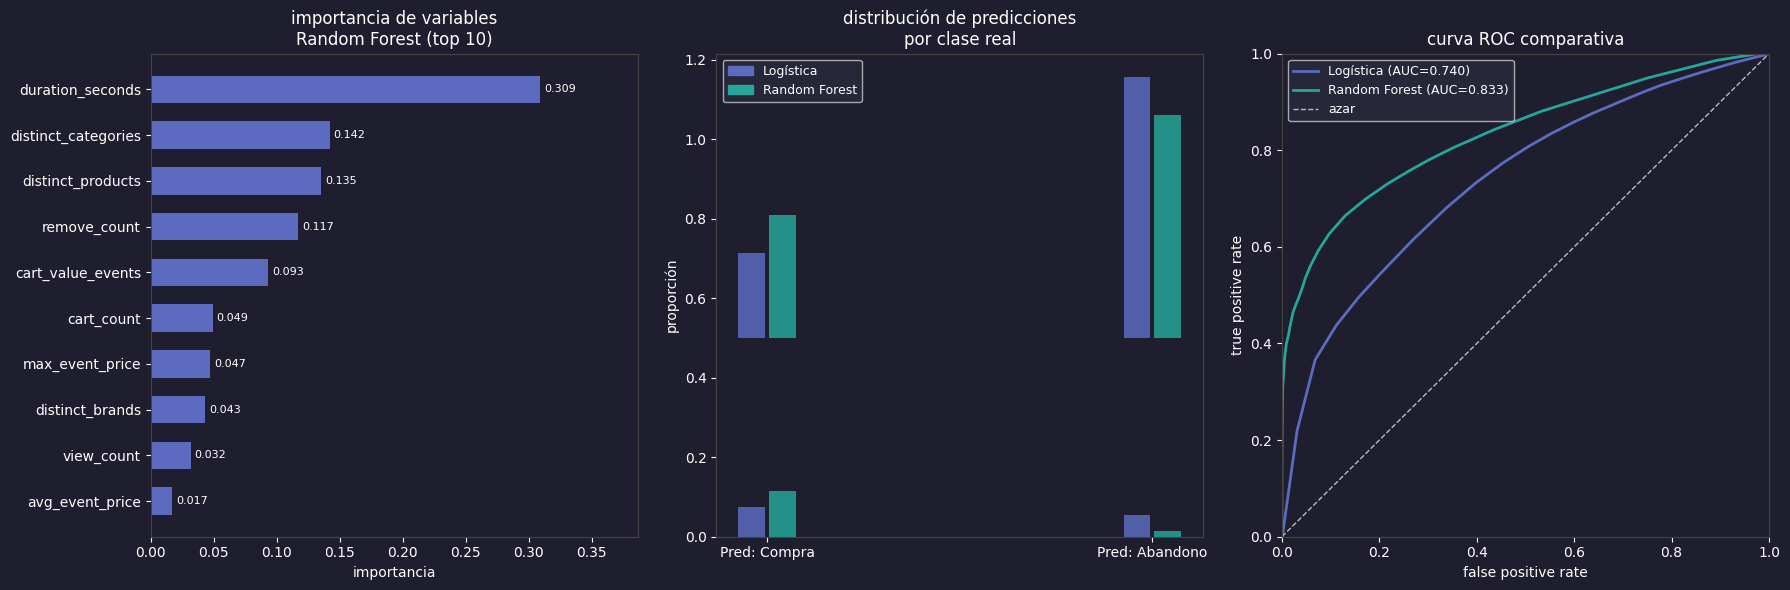

In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

C_MAIN  = "#5C6BC0"
C_SEC   = "#26A69A"
C_GRAY  = "#B0BEC5"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#1E1E2E")
for ax in axes:
    ax.set_facecolor("#1E1E2E")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

# 1. importancia de variables top 10
ax1 = axes[0]
top10 = imp.head(10).copy().sort_values("importancia")
bars = ax1.barh(top10["feature"], top10["importancia"], color=C_MAIN, height=0.6)
ax1.set_xlabel("importancia", color="white")
ax1.set_title("importancia de variables\nRandom Forest (top 10)", fontsize=12)
for bar, val in zip(bars, top10["importancia"]):
    ax1.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=8, color="white")
ax1.set_xlim(0, top10["importancia"].max() * 1.25)

# 2. distribucion de predicciones
ax2 = axes[1]
matrices = {
    "Logística":     [[14535, 10847], [42049, 129214]],
    "Random Forest": [[22534,  2848], [60782, 110481]],
}
for idx, (nombre, mat) in enumerate(matrices.items()):
    tn, fp, fn, tp = mat[0][0], mat[0][1], mat[1][0], mat[1][1]
    total = tn + fp + fn + tp
    valores = np.array([[tn/total, fp/total], [fn/total, tp/total]])
    color = C_MAIN if idx == 0 else C_SEC
    for i in range(2):
        for j in range(2):
            offset = idx * 0.08 - 0.04
            ax2.bar(j + offset, valores[i][j], width=0.07,
                    bottom=i * 0.5, color=color, alpha=0.85)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Pred: Compra", "Pred: Abandono"], color="white")
ax2.set_title("distribución de predicciones\npor clase real", fontsize=12)
ax2.set_ylabel("proporción", color="white")
p1 = mpatches.Patch(color=C_MAIN, label="Logística")
p2 = mpatches.Patch(color=C_SEC,  label="Random Forest")
ax2.legend(handles=[p1, p2], facecolor="#2A2A3E", labelcolor="white", fontsize=9)

# 3. curva ROC
ax3 = axes[2]
def roc_points(pred_df, label_col="label_abandonment", n=40):
    thresholds = np.linspace(0.0, 1.0, n)
    tprs, fprs = [], []
    rows = pred_df.select(label_col, "probability").collect()
    labels_arr = np.array([r[label_col] for r in rows])
    probs_arr  = np.array([float(r["probability"][1]) for r in rows])
    for t in thresholds:
        preds = (probs_arr >= t).astype(int)
        tp = ((preds==1) & (labels_arr==1)).sum()
        fp = ((preds==1) & (labels_arr==0)).sum()
        fn = ((preds==0) & (labels_arr==1)).sum()
        tn = ((preds==0) & (labels_arr==0)).sum()
        tprs.append(tp/(tp+fn) if (tp+fn)>0 else 0)
        fprs.append(fp/(fp+tn) if (fp+tn)>0 else 0)
    return fprs, tprs

fpr_lr, tpr_lr = roc_points(pred_lr)
fpr_rf, tpr_rf = roc_points(pred_rf)
ax3.plot(sorted(fpr_lr), sorted(tpr_lr), color=C_MAIN, lw=2, label="Logística (AUC=0.740)")
ax3.plot(sorted(fpr_rf), sorted(tpr_rf), color=C_SEC,  lw=2, label="Random Forest (AUC=0.833)")
ax3.plot([0,1],[0,1], color=C_GRAY, lw=1, linestyle="--", label="azar")
ax3.set_xlabel("false positive rate", color="white")
ax3.set_ylabel("true positive rate", color="white")
ax3.set_title("curva ROC comparativa", fontsize=12)
ax3.legend(facecolor="#2A2A3E", labelcolor="white", fontsize=9)
ax3.set_xlim(0,1); ax3.set_ylim(0,1)

plt.tight_layout()
plt.show()

In [0]:
%sql
SELECT * FROM ecommerce_history.events_history.gold_funnel

total_sesiones,sesiones_con_vista,sesiones_con_carrito,sesiones_con_compra,tasa_view_a_cart,tasa_cart_a_purchase,tasa_conversion_general
4520615,4266222,983986,155617,0.2306,0.1581,0.0365


In [0]:
%sql
SELECT * FROM ecommerce_history.events_history.gold_tendencia_mensual
ORDER BY cohort_month

cohort_month,total_sesiones,sesiones_con_vista,sesiones_con_compra,tasa_conversion_mensual
2019-10,871629,823882,29743,0.0361
2019-11,935916,877601,36269,0.0413
2019-12,834307,789061,28629,0.0363
2020-01,960857,908570,32097,0.0353
2020-02,917906,867108,28879,0.0333


In [0]:
%sql
SELECT category_level_1, tasa_abandono, tasa_conversion, total_carritos
FROM ecommerce_history.events_history.gold_abandono_segmento
WHERE total_carritos > 1000
ORDER BY tasa_abandono DESC
LIMIT 15

category_level_1,tasa_abandono,tasa_conversion,total_carritos
unknown,0.9284,0.187,34408
unknown,0.906,0.2007,243353
unknown,0.8948,0.1957,29160
unknown,0.8929,0.1293,1755
unknown,0.8834,0.2101,55119
unknown,0.858,0.1713,28613
unknown,0.8457,0.2014,57406
unknown,0.836,0.2195,119556
unknown,0.8164,0.1777,13729
unknown,0.8081,0.2485,6635
